In [1]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx


def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)

    # time-dependent Hamiltonian
    H_td = [H0 + H2 + H_int, [H1, h_t]]

    # initial state (fully polarized + vacuum)

    en, st = Sx.eigenstates()
    a = np.where(np.isclose(en, max(en)))
    psi_spin = st[a[0][0]]
    psi_ph = basis(n_ph, 0)
    psi0 = tensor(psi_spin, psi_ph)
    # evolve
    result = mesolve(H_td,psi0,tlist,[],[Sx_full / N, Sz_full / N],args=args,options=args['opts'])

    
    steady_sx = result.expect[0][-100000:]
    steady_sz = result.expect[1][-100000:]
    op_Sx_avg = np.average(steady_sx)
    op_Sz_avg = np.average(steady_sz)

    return op_Sx_avg, op_Sz_avg



100%|██████████| 30/30 [05:46<00:00, 11.56s/it]


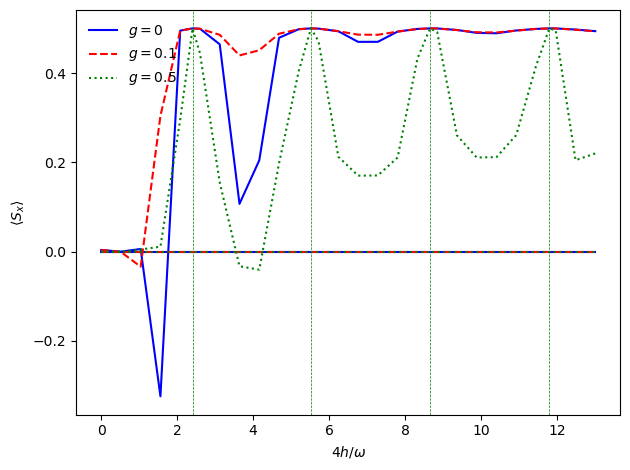

In [ ]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing points
frz = jn_zeros(0, 4)

# parameters
N = 10
hbar = 1.0
h0 = 0
n_ph = 11
#g = 0.5
omega0 = 1.0
Jvalue = 1.0

omega = 90

hs = np.linspace(0, 13, 26) * omega / 4
hs = np.sort(np.append(hs, frz * omega / 4))

# time
ttop = 1000
tlist = np.linspace(0, ttop, ttop * 200 + 1)
opts = Options(nsteps =1e6, atol=1e-10, rtol=1e-8, max_step=0.001)

gvals = [0, 0.1, 0.5]
colors = ['blue', 'red', 'green']
styles = ['-', '--', ':']

for g, c, s  in zip(gvals, colors, styles):
   args_list = [{'omega': omega, 'h0': h0, 'g': g, 'tlist': tlist, 'N': N, 'n_ph': n_ph, 'hbar': hbar, 'omega0': omega0, 'Jvalue': Jvalue, 'h':h, 'opts':opts } 
                for h in hs]

  # parallel run

   p = Pool(processes=10)
   results = p.map(run_dynamics_lmg, tqdm(args_list))

   p.close()
   p.join()

   results = np.array(results)
   Sx_avgs = results[:, 0]
   Sz_avgs = results[:, 1]
   np.savez(f'localization_thermalization_nph_{n_ph}_g_{g}.npz', x = 4*hs/omega, sx = Sx_avgs, sz = Sz_avgs)

   # plot
   plt.plot(4*hs/omega, Sx_avgs, color=c, linestyle=s, label=rf'$g={g}$')
   plt.plot(4*hs/omega, Sz_avgs, color=c, linestyle=s)

dt = tlist[1] - tlist[0]
for i in frz:
    plt.axvline(x=i, ls='--', color='green', lw=0.5)

plt.xlabel(r'$4h / \omega$')
plt.ylabel(r'$\langle S_x \rangle$')
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
dt = tlist[1] - tlist[0]
plt.savefig(f'Localization_Thermalization_N_{N}_nph_{n_ph}_omega_{omega}_dt_{dt:.4f}.png', dpi=300, bbox_inches='tight')
plt.show()

FFT

In [3]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx


def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)

    # time-dependent Hamiltonian
    H_td = [H0 + H2 + H_int, [H1, h_t]]

    # initial state (fully polarized + vacuum)

    en, st = Sx.eigenstates()
    a = np.where(np.isclose(en, max(en)))
    psi_spin = st[a[0][0]]
    psi_ph = basis(n_ph, 0)
    psi0 = tensor(psi_spin, psi_ph)
    # evolve
    result = mesolve(H_td,psi0,tlist,[],[Sx_full / N, Sz_full / N],args=args,options=args['opts'])

    Sx_t = result.expect[0]
    Sz_t = result.expect[1]

    return Sx_t, Sz_t



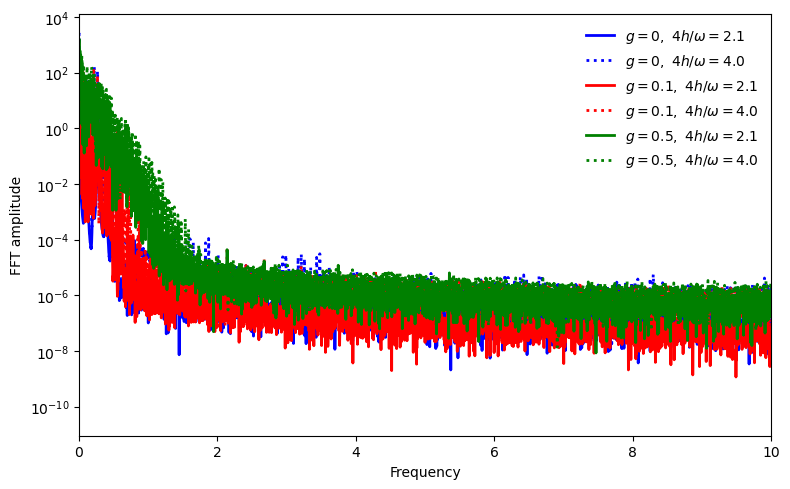

In [ ]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing points
frz = jn_zeros(0, 4)


# parameters
N = 10
hbar = 1.0
h0 = 0
n_ph = 11
omega0 = 1.0
Jvalue = 1.0

omega = 90

# time
ttop = 1000
tlist = np.linspace(0, ttop, ttop * 200 + 1)
opts = Options(nsteps =1e6, atol=1e-10, rtol=1e-8, max_step=0.001,)

dt = tlist[1] - tlist[0]
# near freezing points  
hs_1 = 2.1 * omega / 4

# away from freezing points 
hs_2 = 4 * omega / 4

hs = [hs_1, hs_2]

gvals = [0, 0.1, 0.5]
colors = ['blue', 'red', 'green']

plt.figure(figsize=(8,5))

for g, c  in zip(gvals, colors):
   signals = []
   for h in hs:
       args = {'omega': omega, 'h0': h0, 'g': g, 'tlist': tlist, 'N': N, 'h':h, 'n_ph': n_ph, 'hbar': hbar, 'omega0': omega0, 'Jvalue': Jvalue, 'opts':opts}
       
       Sx_t, Sz_t = run_dynamics_lmg(args)
       
       signals.append(Sx_t)

 # Save Data
   np.savez(f'Sx_fft_data_g_{g}_N_{N}_dt_{dt}.npz', signals=signals, hs=hs, tlist=tlist)  

# FFT

   styles = ['-', ':']
   for signal, h, s in zip(signals, hs, styles):

        signal = signal[-100000:]
        
        signal = signal - np.mean(signal)

        window = np.hanning(len(signal))

        signal = signal * window

        fft_signal = np.abs(np.fft.rfft(signal))

        freq = np.fft.rfftfreq(len(signal),d=dt)

        x = 4 * h / omega
        plt.plot(freq, fft_signal, color=c, linestyle=s, linewidth=2, label=rf'$g={g},\ 4h/\omega={x:.1f}$')

# =====================================================
# Plot settings
# =====================================================

plt.xlim(0,10)

plt.xlabel('Frequency')

plt.ylabel('FFT amplitude')

plt.yscale('log')

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(f'FFT_N_{N}_nph_{n_ph}_omega_{omega}.png', dpi=300, bbox_inches='tight')

plt.show() 



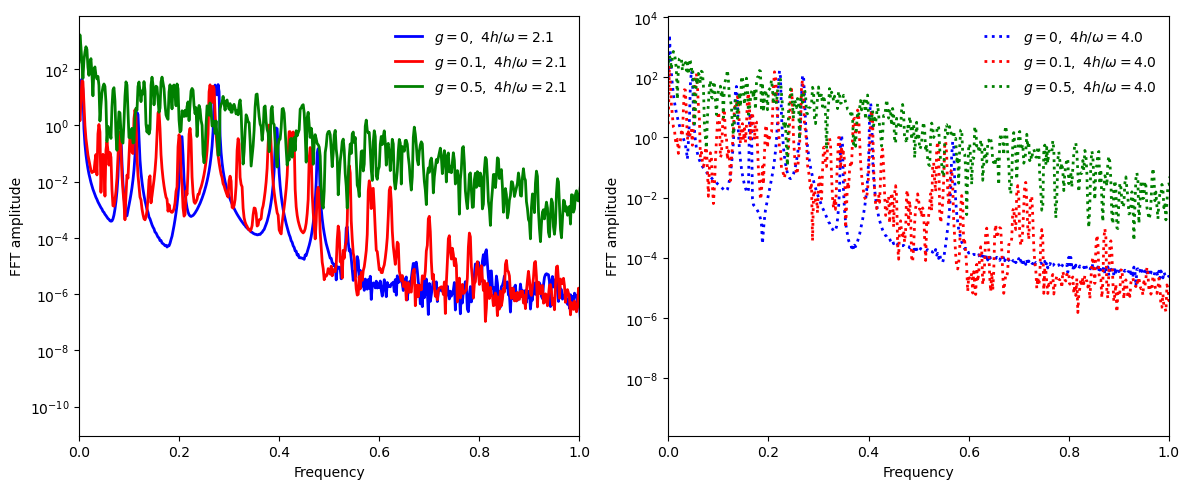

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Parameters
# =====================================================

N = 10
dt = 0.005
omega = 90

gvals = [0, 0.1, 0.5]

colors = ['blue', 'red', 'green']

styles = ['-', ':']

# =====================================================
# Plot late-time signals
# =====================================================

#plt.figure(figsize=(10,6))
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for g, c in zip(gvals, colors):

    # load data
    data = np.load(
        f'Sx_fft_data_g_{g}_N_{N}_dt_{dt}.npz', allow_pickle=True)

    signals = data['signals']

    hs = data['hs']

    tlist = data['tlist']

    # plot both h values
    for signal, h, s, ax in zip(signals, hs, styles, axes):
         signal = signal[-100000:]
        
         signal = signal - np.mean(signal)

         window = np.hanning(len(signal))

         signal = signal * window

         fft_signal = np.abs(np.fft.rfft(signal))

         freq = np.fft.rfftfreq(len(signal),d=dt)

         x = 4 * h / omega
         ax.plot(freq, fft_signal, color=c, linestyle=s, linewidth=2, label=rf'$g={g},\ 4h/\omega={x:.1f}$')
       
         ax.set_xlim(0,1)

         ax.set_xlabel('Frequency')

         ax.set_ylabel('FFT amplitude')

         ax.set_yscale('log')

         ax.legend(frameon=False)

plt.tight_layout()

#plt.savefig(f'FFT_N_{N}_nph_{n_ph}_omega_{omega}.png', dpi=300, bbox_inches='tight')

plt.show() 


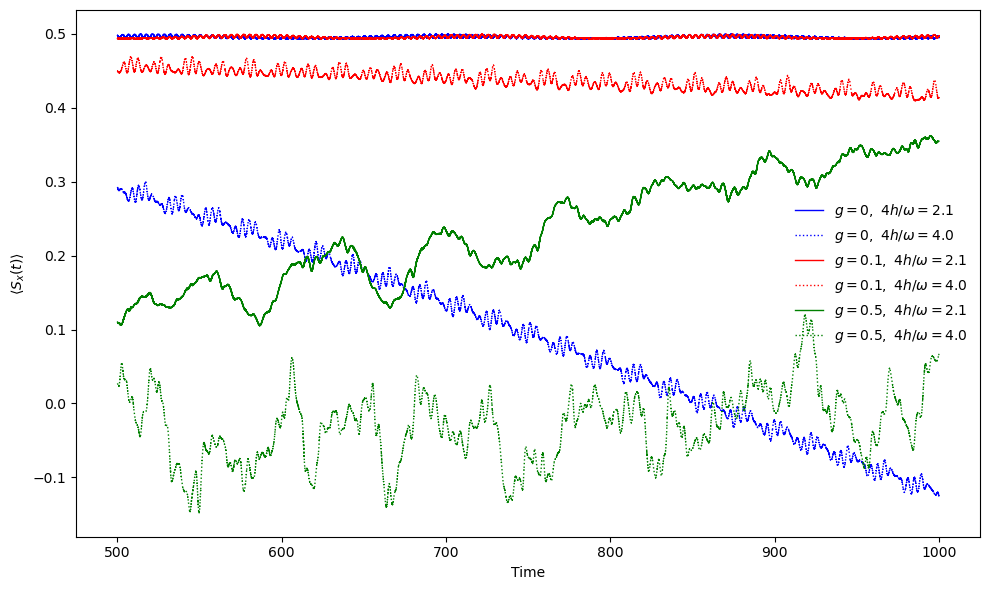

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Parameters
# =====================================================

N = 10
dt = 0.005

gvals = [0, 0.1, 0.5]

colors = ['blue', 'red', 'green']

styles = ['-', ':']

# =====================================================
# Plot late-time signals
# =====================================================

plt.figure(figsize=(10,6))

for g, c in zip(gvals, colors):

    # load data
    data = np.load(
        f'Sx_fft_data_g_{g}_N_{N}_dt_{dt}.npz',
        allow_pickle=True
    )

    signals = data['signals']

    hs = data['hs']

    tlist = data['tlist']

    # plot both h values
    for signal, h, s in zip(signals, hs, styles):

        # late-time region
        signal = signal[-100000:]

        t = tlist[-100000:]

        x = 4*h/90

        plt.plot(
            t,
            signal,
            color=c,
            linestyle=s,
            linewidth=1,
            label=rf'$g={g},\ 4h/\omega={x:.1f}$'
        )

# =====================================================
# Plot settings
# =====================================================

plt.xlabel('Time')

plt.ylabel(r'$\langle S_x(t)\rangle$')

plt.legend(frameon=False)

plt.tight_layout()

#plt.savefig('Late_time_signal.png', dpi=300)

plt.show()

In [19]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)
    n_photon = adag_full * a_full

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx, n_photon


def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx, n_photon = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)

    # time-dependent Hamiltonian
    H_td = [H0 + H2 + H_int, [H1, h_t]]

    # initial state (fully polarized + vacuum)

    en, st = Sx.eigenstates()
    a = np.where(np.isclose(en, max(en)))
    psi_spin = st[a[0][0]]
    psi_ph = basis(n_ph, 0)
    psi0 = tensor(psi_spin, psi_ph)
    # evolve
    result = mesolve(H_td,psi0,tlist,[],[n_photon],args=args,options=args['opts'])

    op_n_photon = result.expect[0]

    return op_n_photon



100%|██████████| 5/5 [00:00<00:00, 228.28it/s]


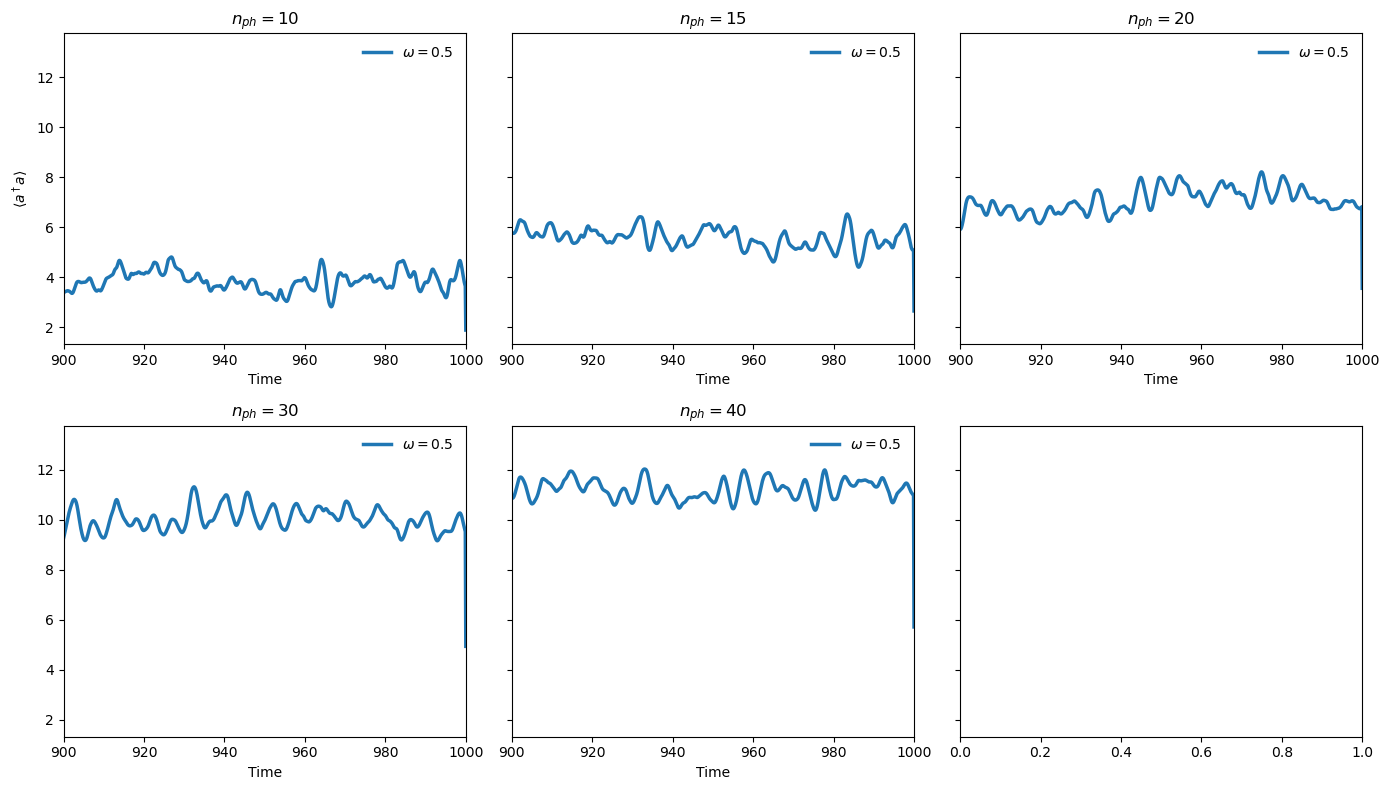

In [20]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing p,oints
frz = jn_zeros(0, 4)

# parameters
N = 10
hbar = 1.0
h0 = 0
g = 0.5
omega0 = 1.0
Jvalue = 1.0

omega = 0.5
x = 2.40
#colors = ['blue', 'red']
nph_vals = [10, 15, 20, 30, 40]

fig, axes = plt.subplots(2,3,figsize=(14,8),sharey=True)
axes = axes.flatten()

# time
ttop = 1000
tlist = np.linspace(0, ttop, ttop * 200 + 1)
opts = Options(nsteps =1e6, atol=1e-10, rtol=1e-8, max_step=0.001)

args_list = []

for n_ph in nph_vals:
        args = {
                'omega': omega,
                'h0': h0,
                'g': g,         
                'tlist': tlist,
                'N': N,
                'n_ph': n_ph,
                'hbar': hbar,
                'omega0': omega0,
                'Jvalue': Jvalue,
                'h': x * omega / 4,
                'opts': opts
        }
        args_list.append(args)

p = Pool(processes=10)
n_photon_t = p.map(run_dynamics_lmg, tqdm(args_list))



colors = ['blue', 'red']                 

#styles = ['-', '--']

for ax, n_ph, signal in zip(axes, nph_vals, n_photon_t):
        
                n_photon_t = signal[-100000:]
                # plot
                window = 50

                smooth_n = np.convolve(n_photon_t,np.ones(window)/window,mode='same')

                # -------------------------------------------------
                # save data
                # -------------------------------------------------

                #np.savez(f'photon_omega_{omega}_nph_{n_ph}.npz',tlist=tlist,n_t=n_photon_t)

                # -------------------------------------------------
                # plot
                # -------------------------------------------------

                ax.plot(tlist[-100000:],smooth_n,linestyle='-',linewidth=2.5,label=rf'$\omega={omega}$')
   
                # =================================================
                # subplot settings
                # =================================================

                ax.set_title(rf'$n_{{ph}}={n_ph}$')

                ax.set_xlabel('Time')

                ax.set_xlim(900,1000)

                ax.legend(frameon=False)

# =====================================================
# common y-label
# =====================================================

axes[0].set_ylabel(r'$\langle a^\dagger a \rangle$')

plt.tight_layout()
  
# =====================================================
# save figure
# =====================================================

omega_string = '_'.join(map(str, [omega]))

nph_string = '_'.join(map(str, nph_vals))

#plt.savefig(f'photon_dynamics_omegas_{omega_string}_nph_{nph_string}.png',dpi=300,bbox_inches='tight')

plt.show()

  

 